In [2]:
# Data Generation Soft and Hard Version
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from docx import Document

# Daten laden
Soft_Version = "C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Fiktive_DataSet_SoftTrick.csv"
Image_SV = r"C:\Users\spast\Desktop\Learning Methods\Data\Images Soft Trick"

Hard_Version = "C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Fiktive_DataSet_HardTrick.csv"
Image_HV = "C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Hard Trick\\"
mode = 0 #int(input("Soft Trick = 0 or Hard Trick = 1"))
if mode == 0:
    filename = Soft_Version
if mode == 1:
    filename = Hard_Version
data = pd.read_csv(filename)

landed
1    556
0    444
Name: count, dtype: int64
landed
1    55.6
0    44.4
Name: proportion, dtype: float64


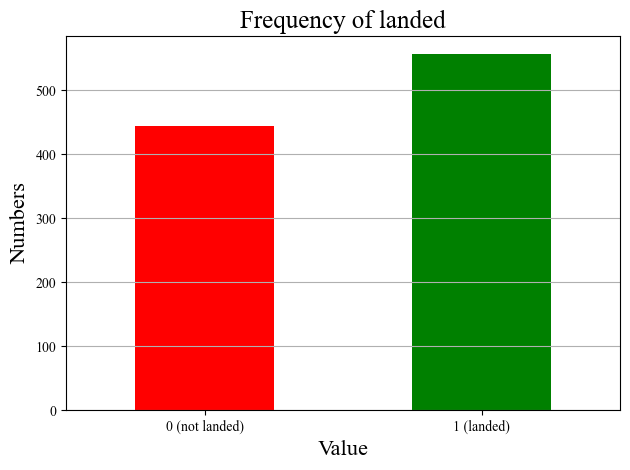

Chi2-Statistik: 12.544
p-Wert: 0.00039748052393435773


In [3]:
# Check Data
counts = data["landed"].value_counts()
print(counts)
percentages = data["landed"].value_counts(normalize=True)*100
print(percentages)
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
data['landed'].value_counts().sort_index().plot(kind='bar', color=['red', 'green'])
plt.title('Frequency of landed', fontsize=18)
plt.xlabel('Value', fontsize=16)
plt.ylabel('Numbers', fontsize=16)
plt.xticks([0, 1], ['0 (not landed)', '1 (landed)'], rotation=0)
plt.grid(axis='y')
plt.tight_layout()
if "Soft" in filename:
    plt.savefig(Image_SV +"Distribution_Soft.png", dpi = 300)
else:
    plt.savefig(Image_HV + "Distribution_Hard.png", dpi = 300)
plt.show()

from scipy.stats import chisquare
# Beobachtete Werte
observed = data['landed'].value_counts().sort_index()
# Erwartete Werte (z. B. gleiche Wahrscheinlichkeit für 0 und 1)
expected = [len(data) / 2, len(data) / 2]
chi2, p = chisquare(f_obs=observed, f_exp=expected)
print("Chi2-Statistik:", chi2)
print("p-Wert:", p) # p > .05 unterscheidet sich nicht von einer 50/50 Verteilung

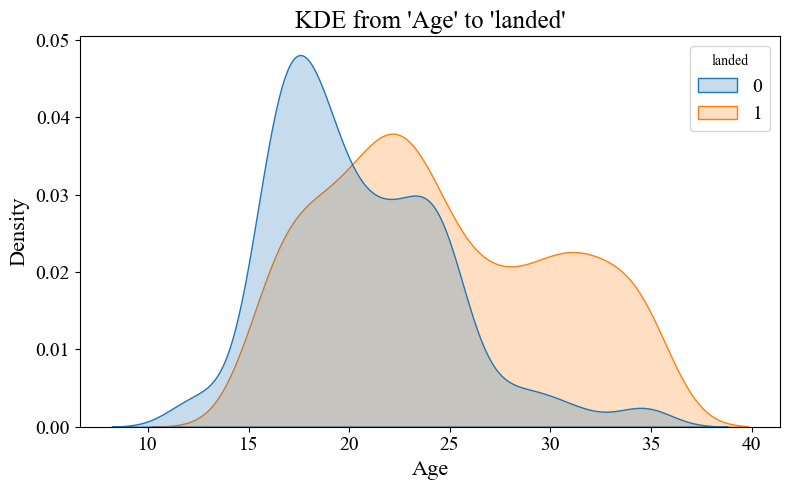

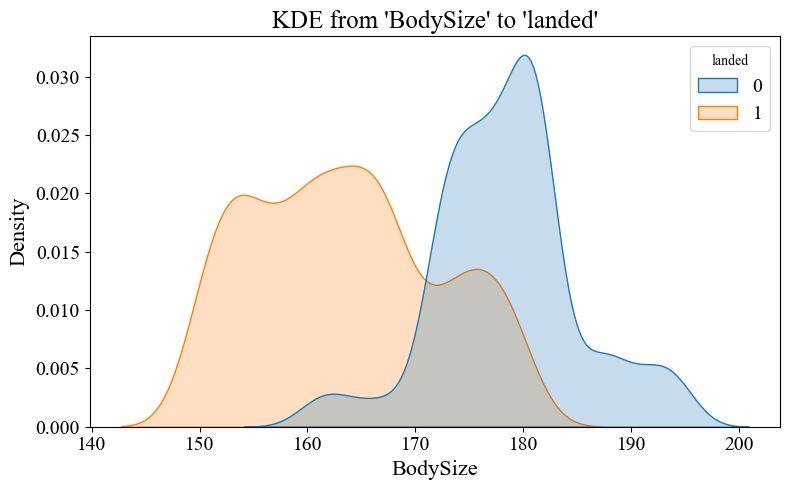

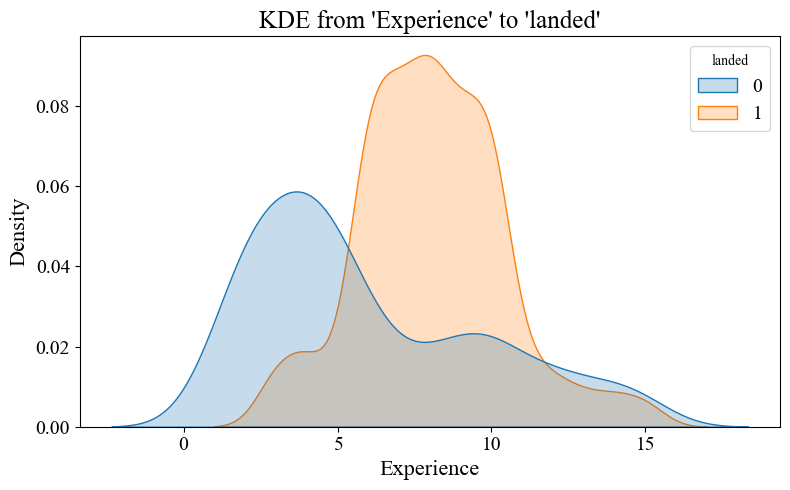

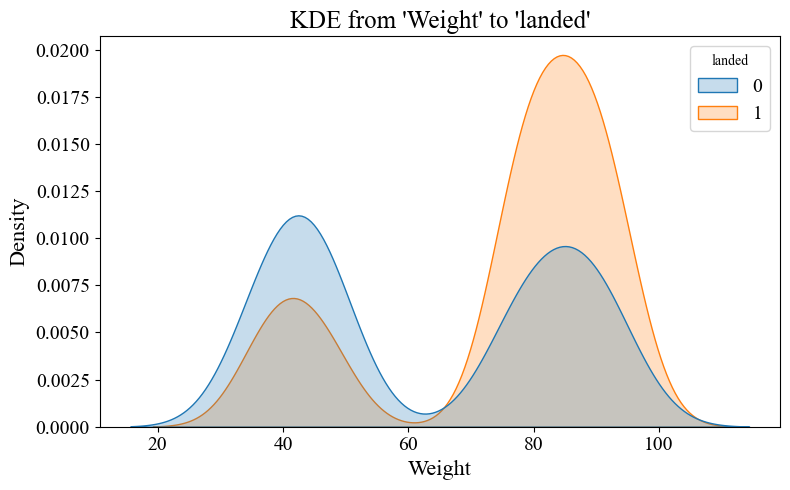

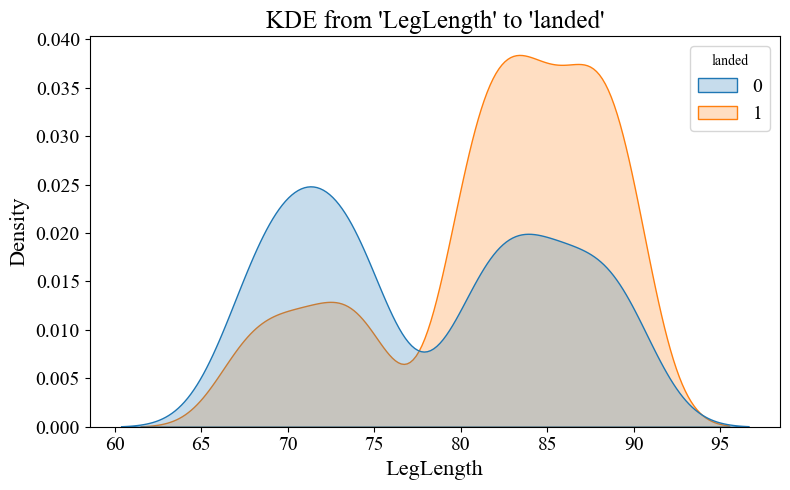

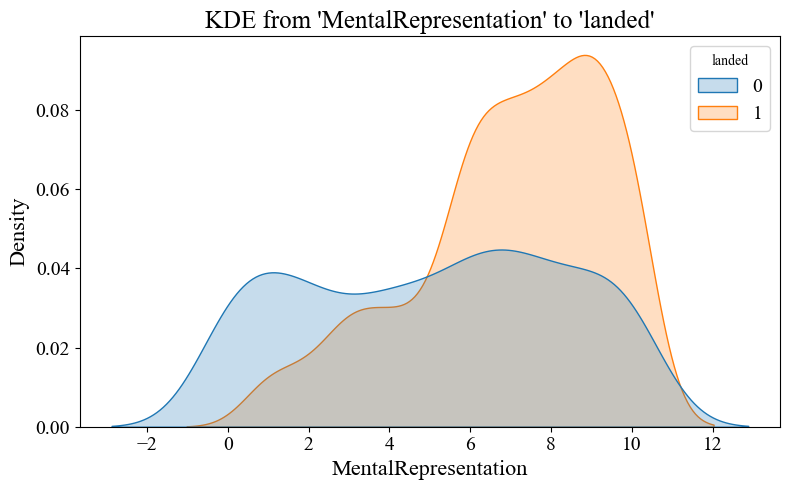

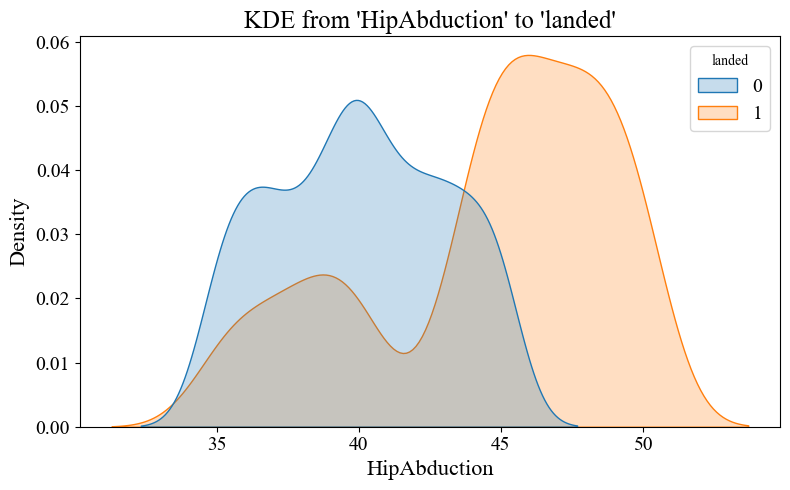

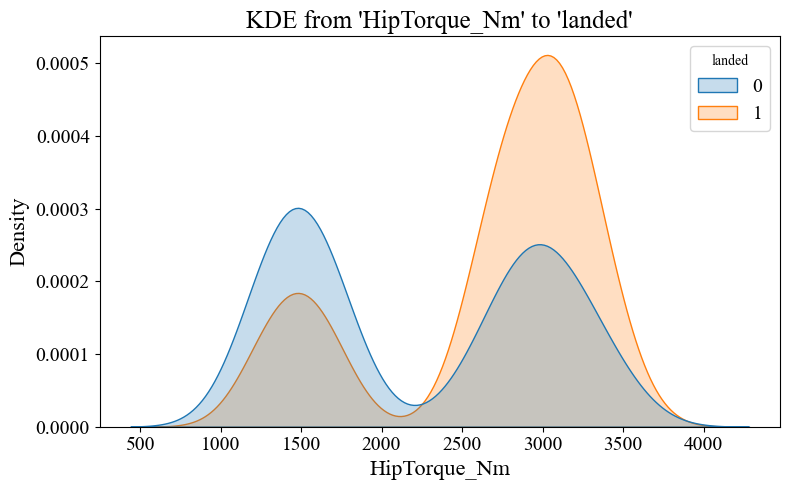

In [4]:
# Kernel Density Estimations
# Schriftart & -größen setzen
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14

# Spalten bereinigen
landed_col = data["landed"]
data = data.drop(columns=data.columns[:2])
data["landed"] = landed_col.astype("category")

# Numerische Spalten auswählen
num_cols = data.select_dtypes(include="number").columns

# Für jede Spalte einen Plot generieren und speichern
for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.kdeplot(data=data, x=col, hue="landed", ax=ax, fill=True)
    ax.set_title(f"KDE from '{col}' to 'landed'")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()
    if "Soft" in filename:
        plt.savefig(Image_SV + f"kde_{col}.png", dpi=300)
    else:
        plt.savefig(Image_HV + f"kde_{col}.png", dpi=300)
    plt.close()

In [5]:
# Model aufteilen und trainieren
X = data[["Age", "BodySize", "Experience", "Weight", "LegLength",
          "MentalRepresentation", "HipAbduction", "HipTorque_Nm"]]
y = data["landed"]  # 0 = Trick nicht gestanden, 1 = Trick gestanden

# Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # 30 % des Testdatensatzes, stratify = Klassenverteilung in Trainings und Testdaten gleich bleibt

# Features skalieren (besonders wichtig für logistische Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Mittelwert aus der Spalte, und die Standardabweichung = (Wert der Spalte - Mittelwert)/Standardabweichung mit den Trainingsdaten 
X_test_scaled = scaler.transform(X_test) #Skalierung mit den Testdaten vornehmen durch das Verwenden des Mittelwertes und Standardabweichung des Trainings

# Modell trainieren
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Confusion Matrix:
 [[117  16]
 [ 31 136]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       133
           1       0.89      0.81      0.85       167

    accuracy                           0.84       300
   macro avg       0.84      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300

Accuracy: 0.8433333333333334
ROC AUC: 0.9391292602764395


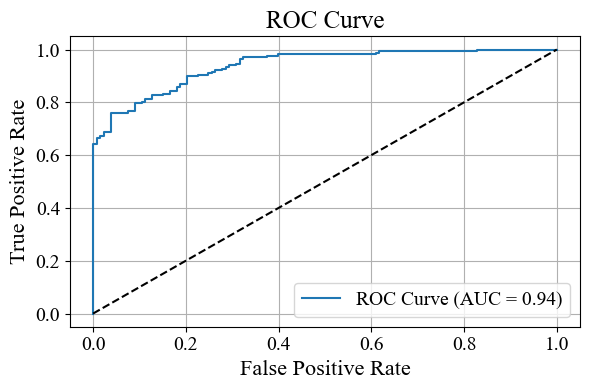

In [6]:
# Vorhersagen
predictions = model.predict(X_test_scaled)
probs = model.predict_proba(X_test_scaled)[:, 1]  # Wahrscheinlichkeit für Klasse 1

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))
print("ROC AUC:", roc_auc_score(y_test, probs))

plt.rcParams["font.family"] = "Times New Roman"
# ROC-Kurve plotten
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, probs)))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonale
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()

In [9]:
# Abspeichern der Daten
# Classification Report als Dictionary
report_dict = classification_report(y_test, predictions, output_dict=True)
# Neues Word-Dokument erstellen
doc = Document()
doc.add_heading('Classification Report', level=1)
# Tabelle erstellen (plus 1 für Kopfzeile)
table = doc.add_table(rows=1 + len(report_dict), cols=5)
table.style = 'Table Grid'
# Kopfzeile definieren
header_cells = table.rows[0].cells
header_cells[0].text = 'Class'
header_cells[1].text = 'Precision'
header_cells[2].text = 'Recall'
header_cells[3].text = 'F1-Score'
header_cells[4].text = 'Support'
# Datenzeilen einfügen
for i, (label, metrics) in enumerate(report_dict.items()):
    row_cells = table.rows[i + 1].cells
    row_cells[0].text = str(label)
    if isinstance(metrics, dict):  # Nur bei Klassen oder "macro avg", etc.
        row_cells[1].text = '{:.2f}'.format(metrics['precision'])
        row_cells[2].text = '{:.2f}'.format(metrics['recall'])
        row_cells[3].text = '{:.2f}'.format(metrics['f1-score'])
        row_cells[4].text = str(int(metrics['support']))
    else:
        row_cells[1].text = row_cells[2].text = row_cells[3].text = str(metrics)
        row_cells[4].text = '-'

if "Soft" in filename:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\roc_curve_soft_trick.png", dpi=300, bbox_inches='tight')  # oder .pdf für Vektorformat
    # Word-Datei speichern
    doc.save("C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\classification_report.docx")
else:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\roc_curve_hard_trick.png", dpi=300, bbox_inches='tight')  # oder .pdf für Vektorformat
    doc.save("C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\classification_report.docx")
#plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
# Neuen Athleten starten
def TestingNewAthlete(age = 22, bodysize = 178, experience = 3, weight = 70, leglength = 90,
                      mentalrepresentation = 4, hipabduction = 35, hiptorquenm = 130):
    new_athlete = {
    "Age": age,
    "BodySize": bodysize,
    "Experience": experience,
    "Weight": weight,
    "LegLength": leglength,
    "MentalRepresentation": mentalrepresentation,
    "HipAbduction": hipabduction,
    "HipTorque_Nm": hiptorquenm
    }
    new_data = pd.DataFrame([new_athlete])
    new_data_scaled = scaler.transform(new_data)
    predicted_class = model.predict(new_data_scaled)
    print("Vorhersage (0 = nicht gestanden, 1 = gestanden):", predicted_class[0])
    prob_success = model.predict_proba(new_data_scaled)[0][1]
    print("Wahrscheinlichkeit für Gelingen (Klasse 1): {:.2f}%".format(prob_success * 100))
    prozent = prob_success * 100
        # Word-Dokument erzeugen
    doc = Document()
    doc.add_heading("Ergebnis für neuen Athleten", level=1)
    
    # Eingabewerte auflisten
    doc.add_paragraph("Eingabewerte:")
    for key, value in new_athlete.items():
        doc.add_paragraph(f"{key}: {value}", style='List Bullet')
    
    # Ergebnistext
    text = f"\nEin Athlet mit den oben genannten Eigenschaften hat eine geschätzte Wahrscheinlichkeit von {prozent:.2f}% den Trick zu stehen."
    if predicted_class == 1:
        text += " Das Modell prognostiziert, dass der Athlet den Trick stehen wird."
    else:
        text += " Das Modell prognostiziert, dass der Athlet den Trick **nicht** stehen wird."
    doc.add_paragraph(text)
    
    # Dokument speichern
    if "Soft" in filename:
        doc.save("C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\TestingNewAthlete_Report.docx")   
    if "Hard" in filename:
        doc.save("C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\TestingNewAthlete_Report.docx")
    print("Word-Datei wurde gespeichert.")

TestingNewAthlete(age=30, bodysize=160, weight=79, experience=5, leglength=85,
                  mentalrepresentation=7, hipabduction=49, hiptorquenm=100)

Vorhersage (0 = nicht gestanden, 1 = gestanden): 1
Wahrscheinlichkeit für Gelingen (Klasse 1): 99.82%
Word-Datei wurde gespeichert.


In [11]:
# Genauigkeit überprüfen
def RunTestingForDataset(dataset, n=1000):
    predictions_list = []
    probabilities_list = []

    for idx, row in dataset.head(n).iterrows():
        # Daten für den Athleten extrahieren
        new_athlete = {
            "Age": row["Age"],
            "BodySize": row["BodySize"],
            "Experience": row["Experience"],
            "Weight": row["Weight"],
            "LegLength": row["LegLength"],
            "MentalRepresentation": row["MentalRepresentation"],
            "HipAbduction": row["HipAbduction"],
            "HipTorque_Nm": row["HipTorque_Nm"]
        }

        new_data = pd.DataFrame([new_athlete])
        new_data_scaled = scaler.transform(new_data)

        # Vorhersage
        predicted_class = model.predict(new_data_scaled)[0]
        prob_success = model.predict_proba(new_data_scaled)[0][1] * 100  # in Prozent

        # In Listen speichern
        predictions_list.append(predicted_class)
        probabilities_list.append(prob_success)

        # Optional: Ausgabe
        print(f"\n--- Athlet {idx+1} ---")
        print(f"Vorhersage: {predicted_class} | Wahrscheinlichkeit: {prob_success:.2f}%")

    return predictions_list, probabilities_list

# Aufruf
predictions, probabilities = RunTestingForDataset(data, n=1000)

# Annahme: predictions und probabilities existieren schon
results = list(zip(predictions, probabilities))
# Liste von Tupeln in DataFrame umwandeln
results_df = pd.DataFrame(results, columns=["Prediction", "Probability"])
index_list = list(range(1, 1001))

# Füge sie als erste Spalte hinzu
results_df.insert(0, "Index", index_list)
# In CSV speichern
results_df.to_csv("results.csv", index=False)

# Beispielausgabe
for idx, row in results_df.iterrows():
    print(f"Athlet {idx+1}: Vorhersage = {row['Prediction']}, Wahrscheinlichkeit = {row['Probability']:.2f}%")

from sklearn.metrics import accuracy_score

# Annahme: data["landed"] existiert und ist die Zielvariable
true_labels = data["landed"].head(1000)

# Genauigkeit berechnen
accuracy = accuracy_score(true_labels, predictions) * 100
print(f"Übereinstimmung: {accuracy:.2f}%")


--- Athlet 1 ---
Vorhersage: 0 | Wahrscheinlichkeit: 4.26%

--- Athlet 2 ---
Vorhersage: 0 | Wahrscheinlichkeit: 3.21%

--- Athlet 3 ---
Vorhersage: 0 | Wahrscheinlichkeit: 2.37%

--- Athlet 4 ---
Vorhersage: 1 | Wahrscheinlichkeit: 70.17%

--- Athlet 5 ---
Vorhersage: 0 | Wahrscheinlichkeit: 1.30%

--- Athlet 6 ---
Vorhersage: 0 | Wahrscheinlichkeit: 17.69%

--- Athlet 7 ---
Vorhersage: 1 | Wahrscheinlichkeit: 58.77%

--- Athlet 8 ---
Vorhersage: 0 | Wahrscheinlichkeit: 38.43%

--- Athlet 9 ---
Vorhersage: 0 | Wahrscheinlichkeit: 38.04%

--- Athlet 10 ---
Vorhersage: 0 | Wahrscheinlichkeit: 4.99%

--- Athlet 11 ---
Vorhersage: 0 | Wahrscheinlichkeit: 37.44%

--- Athlet 12 ---
Vorhersage: 0 | Wahrscheinlichkeit: 8.46%

--- Athlet 13 ---
Vorhersage: 0 | Wahrscheinlichkeit: 9.63%

--- Athlet 14 ---
Vorhersage: 0 | Wahrscheinlichkeit: 5.57%

--- Athlet 15 ---
Vorhersage: 0 | Wahrscheinlichkeit: 34.06%

--- Athlet 16 ---
Vorhersage: 1 | Wahrscheinlichkeit: 60.97%

--- Athlet 17 ---
Vorher


Feature coefficients of the logistic regression (standardized features):
Age: 0.1463
BodySize: -2.1326
Experience: 0.3477
Weight: 0.6545
LegLength: 0.2813
MentalRepresentation: 0.6373
HipAbduction: 1.1698
HipTorque_Nm: -0.3108


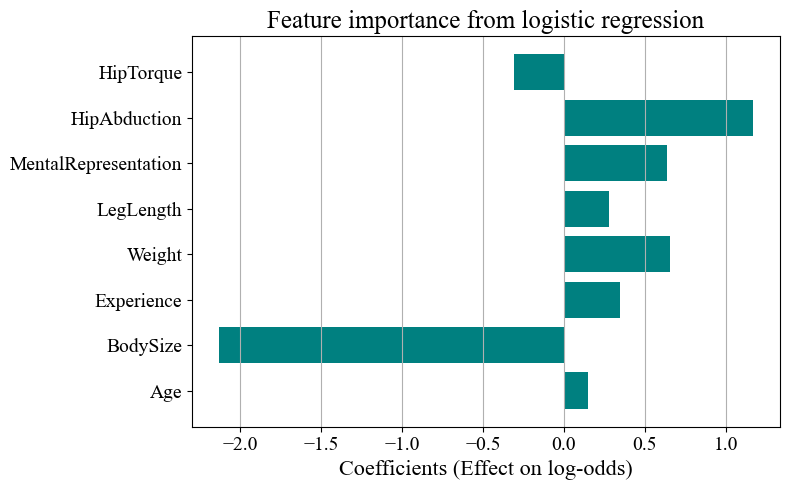


Odds Ratios (based on standardized features):
                Feature  Odds Ratio  Coeffizient
6          HipAbduction    3.221275     1.169777
3                Weight    1.924241     0.654532
5  MentalRepresentation    1.891410     0.637323
2            Experience    1.415804     0.347698
4             LegLength    1.324812     0.281271
0                   Age    1.157561     0.146315
7          HipTorque_Nm    0.732824    -0.310849
1              BodySize    0.118528    -2.132608


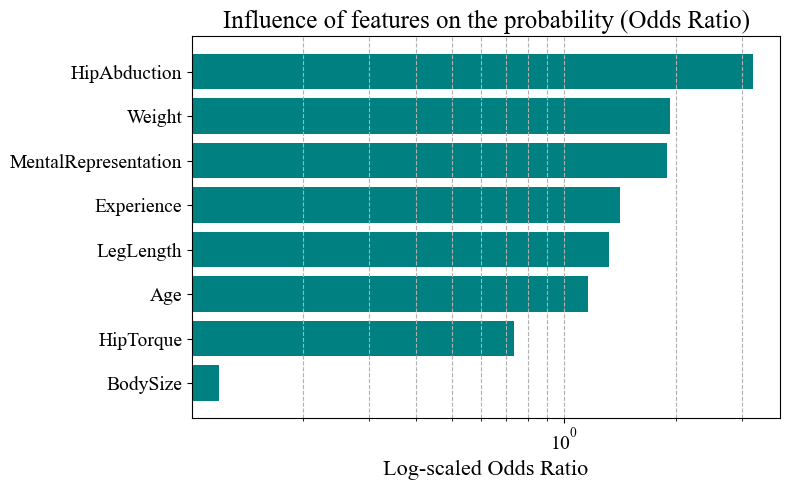

In [14]:
# Log Odds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\nFeature coefficients of the logistic regression (standardized features):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# Koeffizienten
coefs = model.coef_[0]

# Feature-Namen kürzen für die Visualisierung
feature_labels = [f.replace("_Nm", "") for f in X.columns]

# --- Visualisierung der Koeffizienten ---
plt.figure(figsize=(8,5))
plt.barh(feature_labels, coefs, color='teal')
plt.xlabel("Coefficients (Effect on log-odds)")
plt.title("Feature importance from logistic regression")
plt.grid(axis='x')
plt.tight_layout()

# Grafik speichern
if "Soft" in filename:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\" + "Feature_Importance_LogReg.png", dpi=300)
else:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\" + "Feature_Importance_LogReg.png", dpi=300)
plt.show()

# --- Odds Ratios ---
odds_ratios = np.exp(model.coef_[0])  # e^beta
odds_ratios_df = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': odds_ratios,
    'Coeffizient': model.coef_[0]
})

print("\nOdds Ratios (based on standardized features):")
print(odds_ratios_df.sort_values("Odds Ratio", ascending=False))

plt.figure(figsize=(8, 5))
sorted_df = odds_ratios_df.sort_values("Odds Ratio", ascending=True)

# Feature-Namen kürzen für Odds-Ratio Grafik
sorted_feature_labels = [f.replace("_Nm", "") for f in sorted_df["Feature"]]

plt.barh(sorted_feature_labels, sorted_df["Odds Ratio"], color='teal')
plt.xscale("log")  # log-Skala für bessere Lesbarkeit
plt.xlabel("Log-scaled Odds Ratio")
plt.title("Influence of features on the probability (Odds Ratio)")
plt.grid(True, which="both", axis="x", linestyle="--")
plt.tight_layout()

# Grafik speichern
if "Soft" in filename:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\" + "Odds_Ratios_LogReg.png", dpi=300)
else:
    plt.savefig("C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\" + "Odds_Ratios_LogReg.png", dpi=300)
plt.show()

In [15]:
# Signifikante Einflussnahme der Features
import statsmodels.api as sm
# X und y definieren
X = data[["Age", "Experience", "BodySize", "HipAbduction", "Weight", 
          "MentalRepresentation", "LegLength", "HipTorque_Nm"]]
X = sm.add_constant(X)  # Intercept hinzufügen
y = data["landed"].astype(int)  # y sollte integer sein

# Modell fitten
model = sm.Logit(y, X)
result = model.fit()

# Zusammenfassung anzeigen
print(result.summary())
# Zusammenfassung in DataFrame
summary_table = pd.DataFrame({
    "Feature": result.params.index,
    "Coeffizient (β)": result.params.values,
    "Odds Ratio (e^β)": np.exp(result.params.values),
    "p-value": result.pvalues,
    "95% CI Lower Bound": np.exp(result.conf_int()[0]),
    "95% CI Upper Bound": np.exp(result.conf_int()[1])
})

# Sortiert nach kleinsten p-Werten (bedeutungsvollste Features oben)
summary_table = summary_table.sort_values("p-value")

# Ausgabe
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary_table)
# Neues Word-Dokument erstellen
doc = Document()
doc.add_heading('Logistic Regression: Summary of Features', level=1)

# Tabelle erstellen
table = doc.add_table(rows=1, cols=len(summary_table.columns))
table.style = 'Table Grid'

# Kopfzeile einfügen
hdr_cells = table.rows[0].cells
for i, col_name in enumerate(summary_table.columns):
    hdr_cells[i].text = str(col_name)

# Datenzeilen einfügen
for _, row in summary_table.iterrows():
    row_cells = table.add_row().cells
    for i, val in enumerate(row):
        if isinstance(val, float):
            row_cells[i].text = f"{val:.4f}"
        else:
            row_cells[i].text = str(val)

# Speichern – je nach Trick-Modus in richtigen Ordner
if "Soft" in filename:
    output_path = "C:\\Users\\spast\\Desktop\\Learning Methods\\Data\\Images Soft Trick\\feature_significance_logit.docx"
else:
    output_path = "C:\\Users\\spast\\Desktop\\Learning Methods\\Results\\Hard Trick\\feature_significance_logit.docx"

doc.save(output_path)
print("Word-Tabelle wurde gespeichert unter:", output_path)

Optimization terminated successfully.
         Current function value: 0.298206
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 landed   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      991
Method:                           MLE   Df Model:                            8
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.5658
Time:                        19:30:10   Log-Likelihood:                -298.21
converged:                       True   LL-Null:                       -686.86
Covariance Type:            nonrobust   LLR p-value:                1.595e-162
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   16.2709      4.657      3.494      0.000       7.144      25.398